In [1]:
# Install necessary Python packages
!pip install ollama pandas scikit-learn tqdm seaborn -q

# Install Ollama runtime
#!curl -fsSL https://ollama.com/install.sh | sh

In [2]:
import subprocess
import time
import requests
import json
import os
import pandas as pd
import ollama
from pydantic import BaseModel, Field, ValidationError
from typing import List, Literal, Optional
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the model name as a constant to be reused
MODEL_NAME = "qwen3:latest"

In [3]:
def start_ollama():
    """Starts the Ollama server and waits for it to become ready."""
    import subprocess, time, requests
    # Start the server as a background process
    p = subprocess.Popen(["ollama", "serve"])
    print("🚀 Starting Ollama server...")
    # Poll the API endpoint until it's ready
    for _ in range(30):
        try:
            r = requests.get("http://localhost:11434/api/tags", timeout=1)
            if r.status_code == 200:
                print("✅ Ollama server is live and ready.")
                return p
        except (requests.exceptions.ConnectionError, requests.exceptions.ReadTimeout):
            time.sleep(1)
    raise RuntimeError("Ollama server did not start within the expected time.")

# Start the server
server_process = start_ollama()

🚀 Starting Ollama server...
✅ Ollama server is live and ready.


In [4]:
# Pulling the model
#| output: true
print("--- Installed Models (Before Pull) ---")
!ollama list

# Pull the model from the Ollama registry
print(f"\n--- Pulling {MODEL_NAME} ---")
!ollama pull {MODEL_NAME}

# Verify that the model is now available locally
print(f"\n--- Installed Models (After Pull) ---")
!ollama list

--- Installed Models (Before Pull) ---
NAME            ID              SIZE      MODIFIED       
qwen3:latest    500a1f067a9f    5.2 GB    52 minutes ago    

--- Pulling qwen3:latest ---

--- Installed Models (After Pull) ---


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling a3de86cd1c13: 100% ▕██████████████████▏ 5.2 GB                         
pulling ae370d884f10: 100% ▕██████████████████▏ 1.7 KB                         
pulling d18a5cc71b84: 100% ▕██████████████████▏  11 KB                         
pulling cff3f395ef37: 100% ▕██████████████████▏  120 B                         
pulling 05a61d37b084: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest 
writing manifest 
success 


NAME            ID              SIZE      MODIFIED               
qwen3:latest    500a1f067a9f    5.2 GB    Less than a second ago    


In [5]:
hello_resp = ollama.chat(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Say hello in one short sentence."}],
    stream=False,
    think=False
)

print(hello_resp["message"]["content"])

Hello! How can I assist you today?


In [6]:
#Loading the dataset
url = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
df = pd.read_csv(url)

# Display the first few rows of the dataset
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
# Checking for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [8]:
# The most important variables for the analysis are "airline_sentiment" and "text", and they do not have missing values.
# However, for EDA, it will be a problem if there are missing values in other columns.

# I will eliminate airline_sentiment_gold and negativereason_gold because they have mostly missing values and they don't need to be used in the analysis
df = df.drop(columns=['airline_sentiment_gold', 'negativereason_gold'])

# For "negativereason", wI want to be sure that those missing values belong to positive and neutral sentiments only.
df.loc[df['negativereason'].isna(), 'airline_sentiment'].value_counts(normalize=True)

airline_sentiment
neutral     0.567375
positive    0.432625
Name: proportion, dtype: float64

In [9]:
# With this result, we confirm that all missing values in "negativereason" correspond to positive and neutral sentiments.
# This means that for EDA, we cannot analyze "negativereason" for positive and neutral sentiments.

C:\Users\maria\AppData\Local\Temp\ipykernel_32996\1543700402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', palette='viridis')


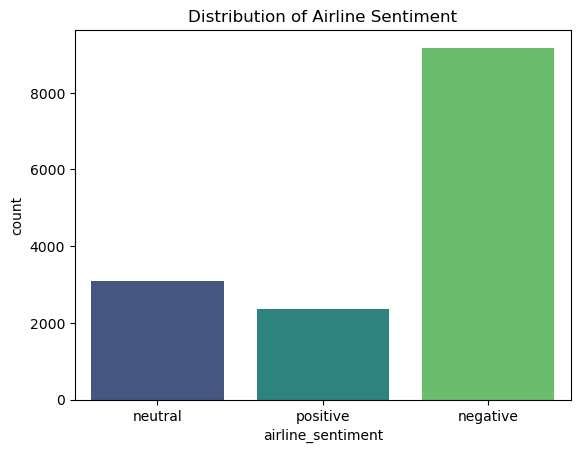

In [10]:
# EDA 

# Sentiment distribution
# Here we will look at the balance between positive, neutral and negative sentiments in the tweets.

sns.countplot(data=df, x='airline_sentiment', palette='viridis')
plt.title("Distribution of Airline Sentiment")
plt.show()

In [11]:
# We can see from the result that most of the tweets have a negative sentiment, and the least have a positive sentiment.

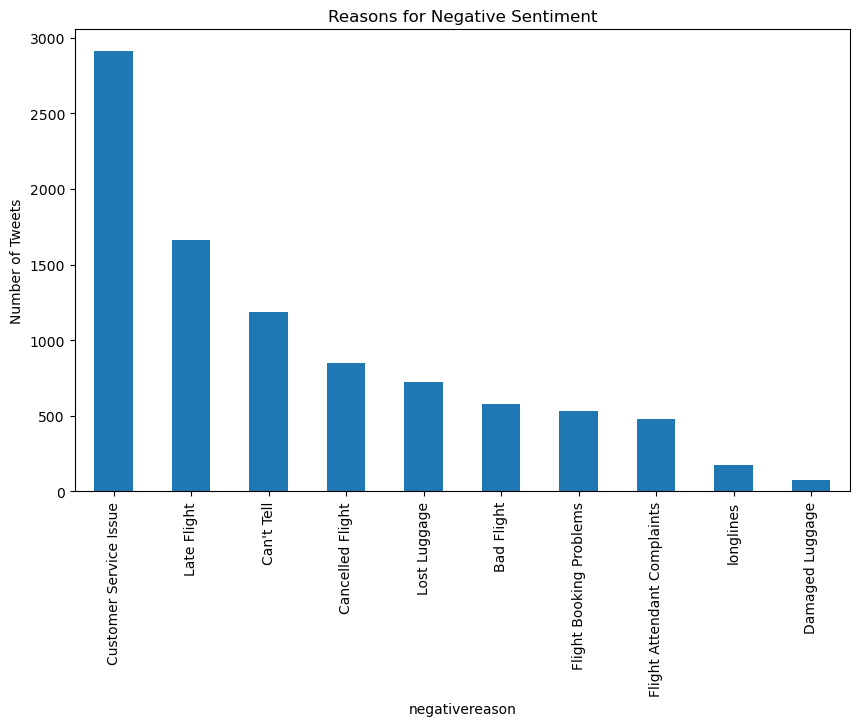

In [12]:
# Looking at the most common reasons for negative sentiments
# For this we need to filter the dataset so that it only includes negative sentiments
neg_reasons = df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts()
neg_reasons.plot(kind='bar', figsize=(10,6))
plt.title("Reasons for Negative Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

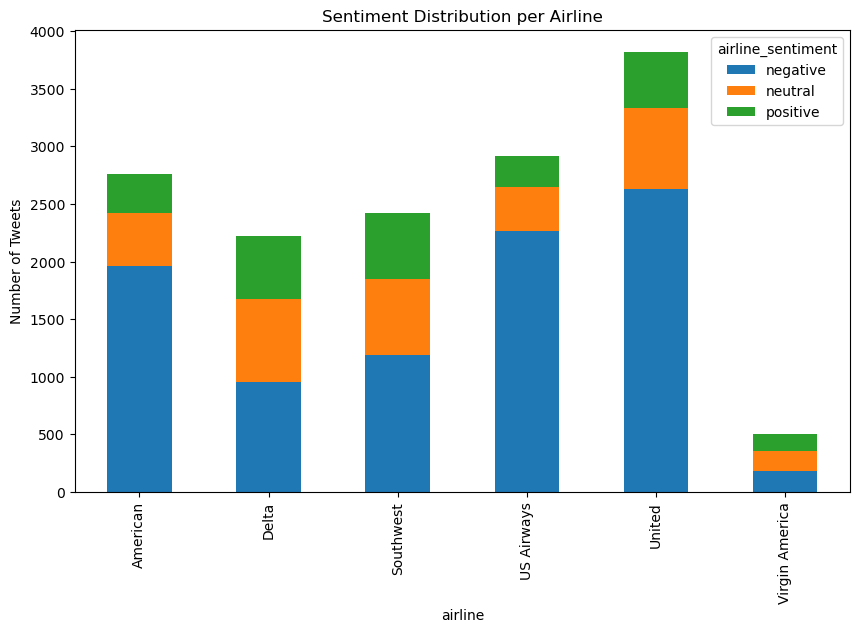

C:\Users\maria\AppData\Local\Temp\ipykernel_32996\293038092.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neg_counts, x='airline', y='negative_count', palette='Reds')


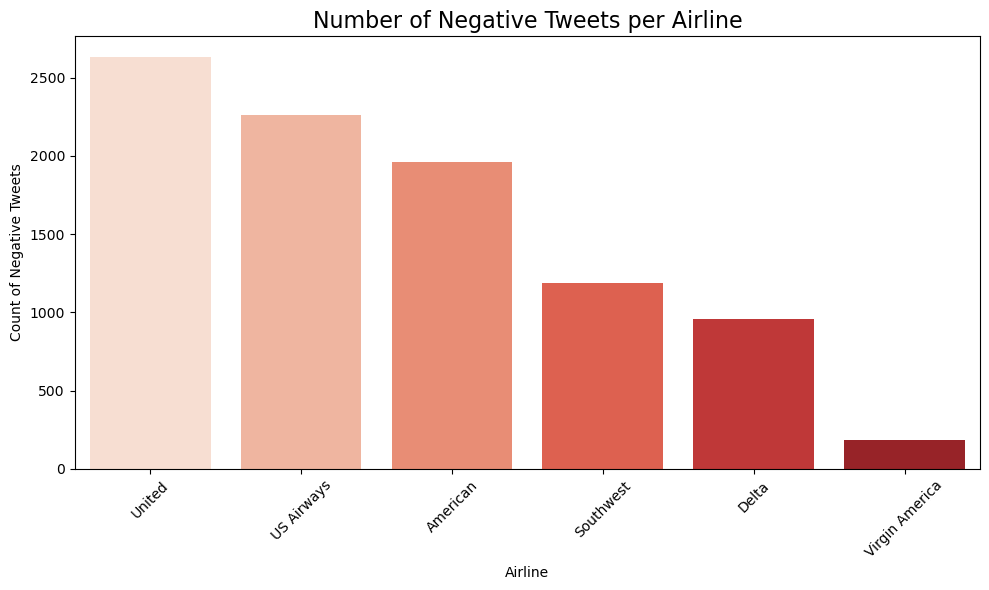

C:\Users\maria\AppData\Local\Temp\ipykernel_32996\293038092.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p_counts, x='airline', y='positive_count', palette='Greens')


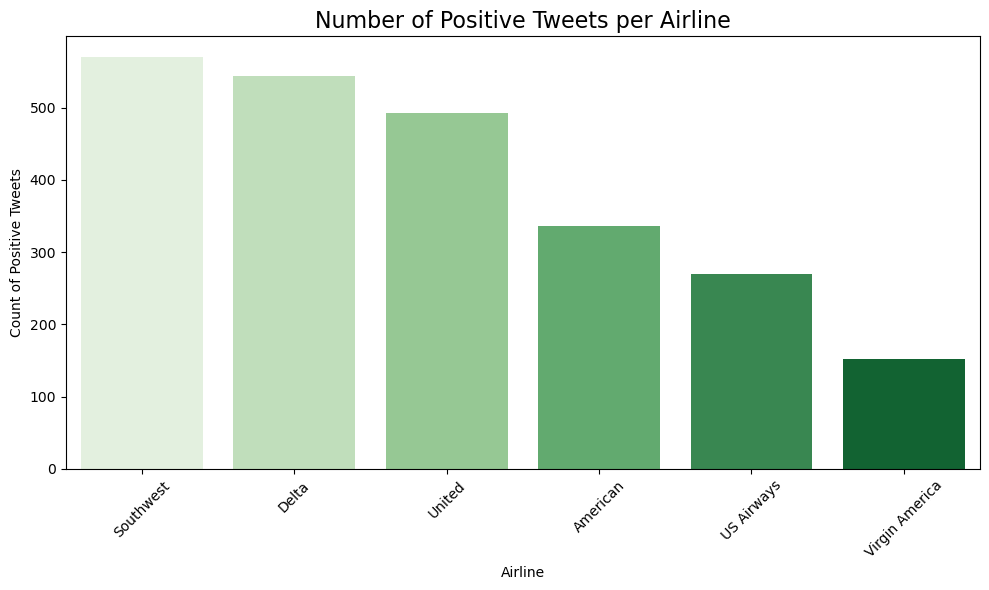

In [13]:
# Sentiment distribution per airline: Looking at which airlines have the most negative, neutral and positive tweets
airline_sentiment_counts = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
airline_sentiment_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment Distribution per Airline")
plt.ylabel("Number of Tweets")
plt.show()

# Only negative sentiments per airline
df_negative = df[df['airline_sentiment'] == 'negative']

neg_counts = df_negative['airline'].value_counts().reset_index()
neg_counts.columns = ['airline', 'negative_count']

plt.figure(figsize=(10,6))
sns.barplot(data=neg_counts, x='airline', y='negative_count', palette='Reds')
plt.title('Number of Negative Tweets per Airline', fontsize=16)
plt.xlabel('Airline')
plt.ylabel('Count of Negative Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Only positive sentiments per airline
df_positive = df[df['airline_sentiment'] == 'positive']
p_counts = df_positive['airline'].value_counts().reset_index()
p_counts.columns = ['airline', 'positive_count']
plt.figure(figsize=(10,6))
sns.barplot(data=p_counts, x='airline', y='positive_count', palette='Greens')
plt.title('Number of Positive Tweets per Airline', fontsize=16)
plt.xlabel('Airline')
plt.ylabel('Count of Positive Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# PART 1: SETUP - CATEGORY MAPPINGS AND SCHEMAS
# =============================================================================

# Define our 3 sentiment categories with numeric IDs
CATEGORY_MAP_BATCHFAST = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Reverse mapping: category name -> ID
CATEGORY_MAP = {v: k for k, v in CATEGORY_MAP_BATCHFAST.items()}

# Short descriptions to help the model understand each category
CATEGORY_DESCRIPTIONS = {
    0: "Tweets expressing complaints, frustration, or dissatisfaction about airline services.",
    1: "Tweets that are factual, descriptive, or without strong emotion toward the airline.",
    2: "Tweets expressing satisfaction, praise, or positive experiences with the airline."
}

# Choose ONE example tweet to show the model (few-shot learning)
# This will guide the model to understand how to classify similar posts
example_tweet = {
    "text": "Flight was delayed and customer service was terrible.",
    "label": "negative"
}

# Convert label to numeric ID
example_label_id = CATEGORY_MAP[example_tweet["label"]]  # This is 0

# Pydantic schema: forces the model to return ONLY a numeric ID
class BatchSentimentAnalysis(BaseModel):
    id: int = Field(
        description="Single best-fit sentiment ID (0=negative, 1=neutral, 2=positive).",
        ge=0,  # Greater than or equal to 0
        le=2   # Less than or equal to 2
    )

In [ ]:
# =============================================================================
# PART 2: THE CLASSIFICATION FUNCTION
# =============================================================================

def classify_sentiment_fast(
    post: dict,
    example_tweet_input: dict,
    example_tweet_id: int
) -> Optional[int]:
    """
    Fast one-shot sentiment classifier that returns ONLY a sentiment ID (0-2).
    
    This function classifies airline tweets into:
    - 0: negative
    - 1: neutral
    - 2: positive
    
    It uses a single example tweet to guide classification and returns a numeric ID.
    
    Args:
        post: The tweet to classify (must contain a 'text' field)
        example_tweet_input: Example tweet used to guide the model
        example_tweet_id: The numeric sentiment ID for the example
    
    Returns:
        Integer from 0-2 representing the sentiment, or None if error
    """
    
    # --- BUILD THE PROMPT ---
    
    # Create a readable list of sentiment categories for the model
    categories_text = "\n".join(
        f"{cat_id}: {CATEGORY_MAP_BATCHFAST[cat_id]} — {CATEGORY_DESCRIPTIONS[cat_id]}"
        for cat_id in CATEGORY_MAP_BATCHFAST
    )
    
    # System prompt: defines the model’s role
    system_prompt = (
        "You are a fast sentiment classifier. "
        "Your task is to assign EXACTLY ONE sentiment ID to the tweet. "
        "Return ONLY valid JSON with one field 'id'. "
        "No explanations, no extra keys."
    )
    
    # User prompt: provides definitions, example, and the new tweet
    user_prompt = f"""
--- SENTIMENT DEFINITIONS ---
{categories_text}

You MUST pick exactly one sentiment ID (0-2) that best matches the tweet.

--- EXAMPLE ---
INPUT TWEET:
Text: {example_tweet_input['text']}

CORRECT SENTIMENT ID:
{example_tweet_id}

The JSON for that example would be:
{{"id": {example_tweet_id}}}

--- NEW TWEET TO CLASSIFY ---
Text: {post.get('text', '')}

Now return ONLY:
{{"id": <integer from 0 to 2>}}
"""
    
    # --- CALL THE MODEL ---
    
    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",  "content": user_prompt}
            ],
            format=BatchSentimentAnalysis.model_json_schema(),  # Enforce schema
            stream=False,
            think=False
        )
        
        # Parse model output
        raw_json = response["message"]["content"]
        parsed = BatchSentimentAnalysis.model_validate_json(raw_json)
        return parsed.id
    
    except (ValidationError, json.JSONDecodeError) as e:
        print(f"[parse error] {post.get('text', '[no text]')}: {e}")
        return None
    except Exception as e:
        print(f"[other error] {post.get('text', '[no text]')}: {e}")
        return None

In [ ]:
# =============================================================================
# PART 3: SENTIMENT BATCH PROCESSING
# =============================================================================
"""
Now we'll use classify_sentiment_fast() to process a batch of airline tweets.
The key insight: we call the function once per tweet in a loop.
"""

print("="*70)
print("AIRLINE SENTIMENT BATCH INFERENCE")
print("="*70)

# --- Load or create dataset ---
csv_path = "airline_sentiment_dataset.csv"

df = pd.read_csv(csv_path)
print(f"\n✅ Loaded {len(df)} tweets")

# --- Process a subset for testing ---
print(f"\n Classifying first 50 tweets...\n")
subset_df = df.head(50)

sentiment_predictions = []

for idx, row in tqdm(subset_df.iterrows(),
                     total=len(subset_df),
                     desc="One-Shot Sentiment Classification"):
    
    tweet_dict = row.to_dict()
    
    # --- Call our classifier (KEY FUNCTION) ---
    predicted_id = classify_sentiment_fast(
        post=tweet_dict,
        example_tweet_input=example_tweet,
        example_tweet_id=CATEGORY_MAP_REVERSE[example_tweet["label"]]
    )
    
    # Convert ID to readable sentiment label
    predicted_label = CATEGORY_MAP.get(predicted_id, "Unknown")
    
    sentiment_predictions.append({
        "tweet_id": tweet_dict.get("tweet_id", ""),
        "text": tweet_dict.get("text", ""),
        "true_label": tweet_dict.get("airline_sentiment", ""),
        "predicted_id": predicted_id,
        "predicted_label": predicted_label
    })

# --- Build dataframe ---
sentiment_df = pd.DataFrame(sentiment_predictions)

# --- Identify misclassifications ---
misclassified_df = sentiment_df[
    sentiment_df["true_label"] != sentiment_df["predicted_label"]
][["text", "true_label", "predicted_label"]]

print("\n" + "="*70)
print("MISCLASSIFIED TWEETS")
print("="*70)
display(misclassified_df)

# --- Compute accuracy ---
valid_df = sentiment_df[sentiment_df["predicted_label"] != "Unknown"].copy()
if len(valid_df) > 0:
    sentiment_accuracy = accuracy_score(
        valid_df["true_label"],
        valid_df["predicted_label"]
    )
    print(f"\n Sentiment Accuracy: {sentiment_accuracy:.1%}")
else:
    sentiment_accuracy = 0.0
    print("\n No valid predictions")

print("\nClassification Report:")
print(classification_report(
    sentiment_df["true_label"],
    sentiment_df["predicted_label"],
    labels=list(CATEGORY_MAP.values()),
    zero_division=0
))


One-Shot Sentiment Classification:   0%|          | 0/14640 [00:00<?, ?it/s]

One-Shot Sentiment Classification:   3%|▎         | 449/14640 [04:56<2:36:13,  1.51it/s]


KeyboardInterrupt: 